In [1]:
import ROOT as r

In [2]:
%jsroot off

In [3]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
chaingst = r.TChain("gst")
chaingst.Add(prepath+"nu_1year_fluxhanae34.gst.root")
chaingst.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")

chainrootracker = r.TChain("gRooTracker")
chainrootracker.Add(prepath+"nu_1year_fluxhanae34.rootracker.root")
chainrootracker.AddFile("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")
#gstfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
#rootrackerfile = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

#gstfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
#rootrackerfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

#gsttree = gstfile.Get("gst")
#rootrackertree = rootrackerfile.Get("gRooTracker")

#gsttree.AddFriend(rootrackertree)
chaingst.AddFriend(chainrootracker)

In [4]:
df = r.RDataFrame(chaingst);

In [5]:
df1 = df.Define("log10_E","log10(Ev)")
df2 = df1.Define("xsecN_overE","gRooTracker.EvtXSec/(Ev*184)")

In [6]:
#filter per neutrino type
df_numu = df2.Filter("neu==14");
#target must be tungsten
df_numu_W = df_numu.Filter("tgt==1000741840");

In [7]:
import numpy as np
from array import array
# logaritmic binning parameters
nbinsE = 8
E_min = 1.     
E_max = 4000

# Generate borders of logarithms bins
Ebin_borders = np.logspace(np.log10(E_min), np.log10(E_max), nbinsE + 1)

# Conversion to c++
Ebin_borders_c = array('d', Ebin_borders)
nbinsxsec = 1000;
minxsec = 0.;
maxxsec = 1.;

In [8]:
#checking values of bins
Ebin_borders_c

array('d', [1.0, 2.820054483103209, 7.952707287670507, 22.427067839402774, 63.24555320336759, 178.35590584749932, 502.97337187317424, 1418.4123122324825, 4000.000000000001])

In [9]:
# Energy histograms must have same bins as cross sections to attach errors
hE_CC_numu = df_numu_W.Filter("cc").Histo1D(("hE_CC_numu","Energy CC nu mu",nbinsE,Ebin_borders_c),"Ev")
hE_CCDIS_numu = df_numu_W.Filter("cc&&dis").Histo1D(("hE_CCDIS_numu","Energy CCDIS nu mu",nbinsE,Ebin_borders_c),"Ev")

In [10]:
def selectchannel(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_numu_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [11]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [12]:
profiles = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel(cc, inttype, hitnuc,charm);
                profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [13]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles.append(selectdf.Profile1D(("prof_"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [14]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles.append(selectdf.Profile1D(("prof_"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

In [15]:
h_sum = r.TH1D("h_sum","total cross section",nbinsE,Ebin_borders_c)
for profile in profiles:
    h_sum.Add(profile.ProjectionX("h_"+profile.GetName()))

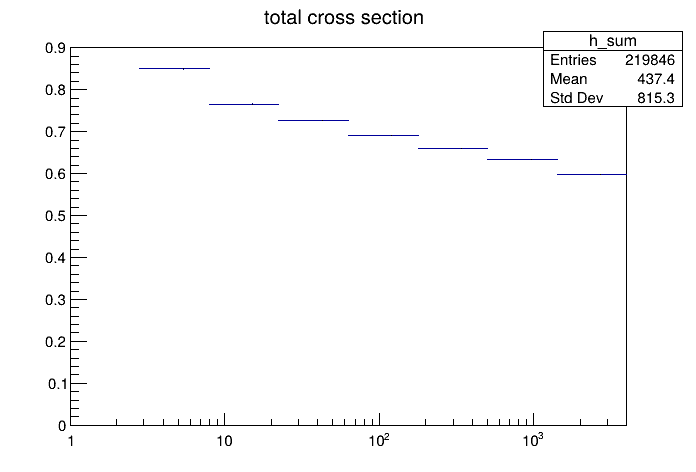

In [16]:
c0 = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,0.9,"Y")
c0.SetLogx()
c0.Draw()

In [17]:
#for prof in profiles:
#    if (prof.GetEntries() > 0):
#        print(prof.GetName(),prof.GetEntries())

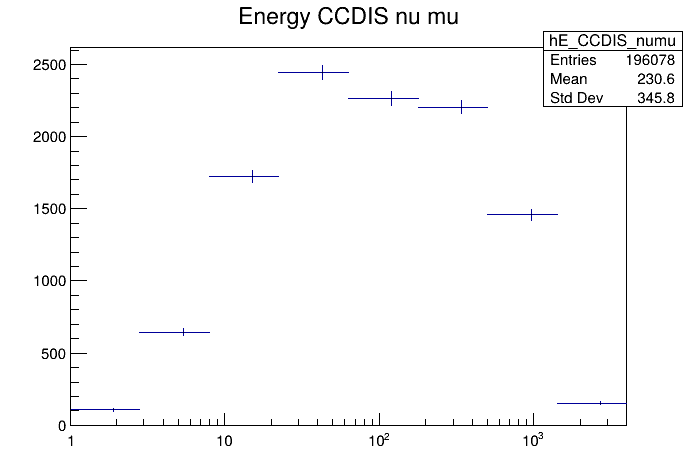

In [18]:
nE_CCDIS_numu = 9.6e+3+1.4e+3
cE_CCDIS_numu = r.TCanvas()
hE_CCDIS_numu.Scale(nE_CCDIS_numu/hE_CCDIS_numu.Integral())
for i in range(1, hE_CCDIS_numu.GetNbinsX() + 1):
    content = hE_CCDIS_numu.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_numu.SetBinError(i, r.TMath.Sqrt(content))
hE_CCDIS_numu.Draw("E")
cE_CCDIS_numu.SetLogx()
cE_CCDIS_numu.Draw()

In [19]:
h_sum_ccdis = r.TH1D("h_sum_ccdis","ccdis cross section numu",nbinsE,Ebin_borders_c)
for profile in profiles:
    if "dis" in profile.GetName():
        h_sum_ccdis.Add(profile.ProjectionX("h_ccdis_"+profile.GetName()))

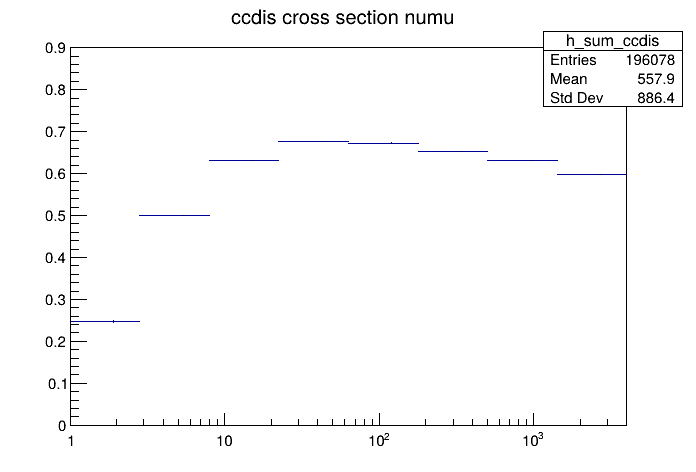

In [20]:
c1 = r.TCanvas()
h_sum_ccdis.Draw()
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
c1.SetLogx()
c1.Draw()

# Now for anti neutrinos

In [21]:
#filter per neutrino type
df_numu_bar = df2.Filter("neu==-14");
#target must be tungsten
df_numu_bar_W = df_numu_bar.Filter("tgt==1000741840");

In [22]:
# Energy histograms must have same bins as cross sections to attach errors
hE_CC_numu_bar = df_numu_bar_W.Filter("cc").Histo1D(("hE_CC_numu_bar","Energy CC nu mu bar",nbinsE,Ebin_borders_c),"Ev")
hE_CCDIS_numu_bar = df_numu_bar_W.Filter("cc&&dis").Histo1D(("hE_CCDIS_numu_bar","Energy CCDIS nu mu bar",nbinsE,Ebin_borders_c),"Ev")

In [23]:
def selectchannel_bar(cc,inttype,hitnuc,charm,sea = "None",hitqrk = "None", resid = "None"):
 dfint = df_numu_bar_W.Filter(cc+"&&"+inttype+"&&"+hitnuc+"&&"+charm)
 if (inttype=="dis"):
     dfintqrk = dfint.Filter(sea+"&&"+hitqrk)
     return dfintqrk
 if (inttype=="res"):
     dfintqrk = dfint.Filter(resid)
     return dfintqrk
 
 else: 
     return dfint
    

In [24]:
charge = ["cc"]
charms = ["charm","!charm"]
inttypes = ["qel","mec","coh","imd","nuel"]


hitnuclei = ["hitnuc==2212","hitnuc==2112"]

In [25]:
profiles_bar = []
for cc in charge:
    for inttype in inttypes:
        for hitnuc in hitnuclei:
            for charm in charms:
                selectdf = selectchannel_bar(cc, inttype, hitnuc,charm);
                profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm,"Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))
            
    

In [26]:
#ccres need to loop over all resids
resonances = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]

for resid in resonances:
    for hitnuc in hitnuclei:
        for charm in charms:
            selectdf = selectchannel_bar("cc", "res", hitnuc,charm,resid=f"resid=={resid}")
            profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_"+inttype+"_"+hitnuc+"_"+charm+f"_resid_{resid}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"))


In [27]:
#profiles = []
#ccdis need to loop over all quarks
quarks = [-6,-5,-4,-3,-2,-1,1,2,3,4,5,6]
sea_valence = ["!sea","sea"]
charge = ["cc"]
hitnuclei = ["hitnuc==2212","hitnuc==2112"]

for cc in charge:
    for charm in charms:
        for hitnuc in hitnuclei:
            for issea in sea_valence:
                for quark in quarks:
                    selectdf = selectchannel_bar(cc,"dis",hitnuc,charm,issea,f"hitqrk=={quark}")
                    profiles_bar.append(selectdf.Profile1D(("prof_bar"+cc+"_dis_"+hitnuc+"_"+charm+"_"+issea+f"_quark_{quark}","Int Profile",nbinsE,Ebin_borders_c,minxsec,maxxsec),"Ev","xsecN_overE"));

### plotting Energy CC

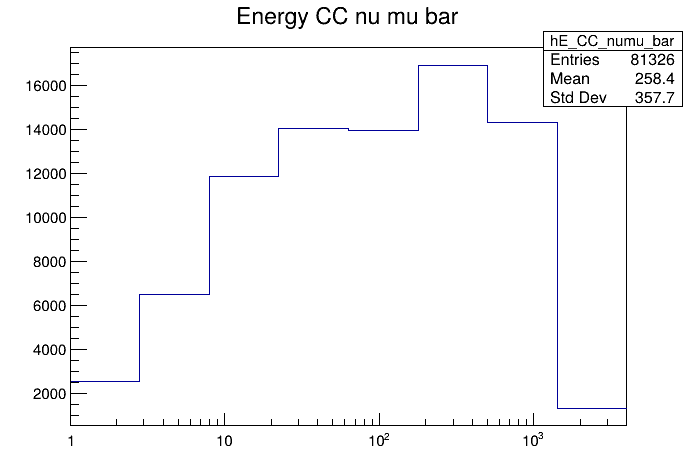

In [28]:
cE_numu_bar = r.TCanvas()
hE_CC_numu_bar.Draw()
cE_numu_bar.SetLogx()
cE_numu_bar.Draw()

In [29]:
h_sum_bar = r.TH1D("h_sum_bar","total cross section anti neutrino",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    h_sum_bar.Add(profile.ProjectionX("h_bar"+profile.GetName()))

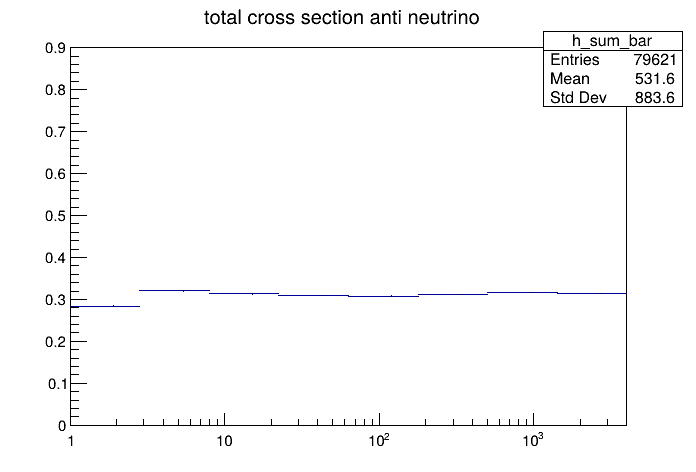

In [30]:
c10 = r.TCanvas()
h_sum_bar.Draw()
h_sum_bar.SetAxisRange(0,0.9,"Y")
c10.SetLogx()
c10.Draw()

In [31]:
#for prof in profiles:
#    if (prof.GetEntries() > 0):
#        print(prof.GetName(),prof.GetEntries())

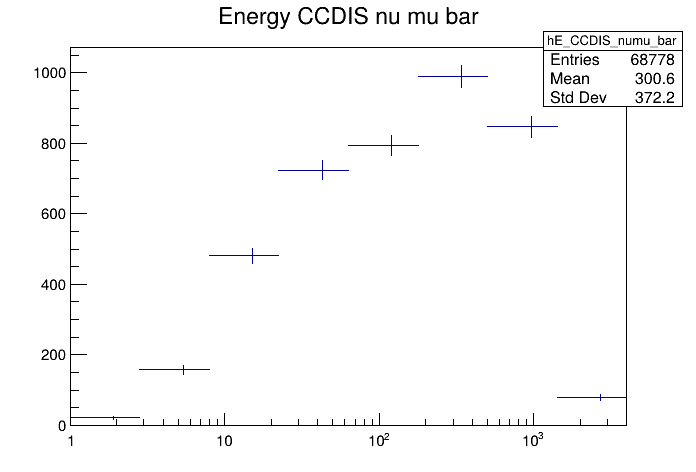

In [32]:
nE_CCDIS_numu_bar = 3.1e+3+9.9e+2
cE_CCDIS_numu_bar = r.TCanvas()
hE_CCDIS_numu_bar.Scale(nE_CCDIS_numu_bar/hE_CCDIS_numu_bar.Integral())
for i in range(1, hE_CCDIS_numu_bar.GetNbinsX() + 1):
    content = hE_CCDIS_numu_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    hE_CCDIS_numu_bar.SetBinError(i, r.TMath.Sqrt(content))
hE_CCDIS_numu_bar.Draw("E")
cE_CCDIS_numu_bar.SetLogx()
cE_CCDIS_numu_bar.Draw()

In [33]:
h_sum_bar_ccdis = r.TH1D("h_sum_bar_ccdis","ccdis cross section anti numu",nbinsE,Ebin_borders_c)
for profile in profiles_bar:
    if "dis" in profile.GetName():
        h_sum_bar_ccdis.Add(profile.ProjectionX("h_ccdis_bar"+profile.GetName()))

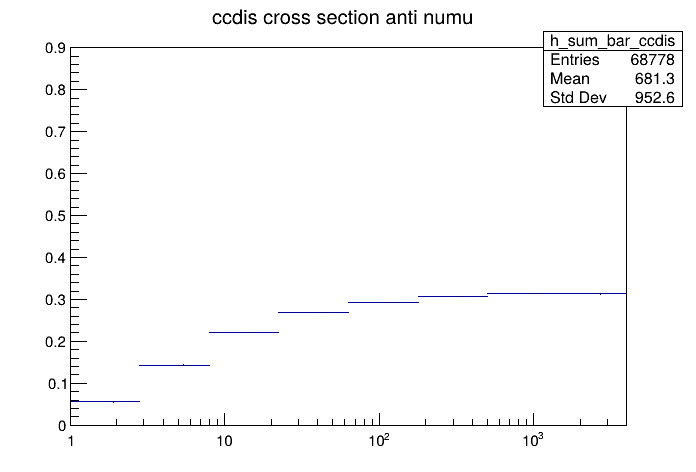

In [34]:
c11 = r.TCanvas()
h_sum_bar_ccdis.Draw()
h_sum_bar_ccdis.SetAxisRange(0,0.9,"Y")
c11.SetLogx()
c11.Draw()

## Including both nu and nu bar

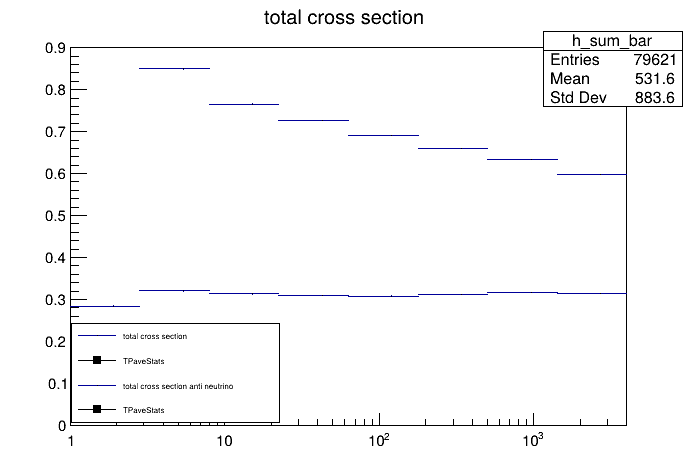

In [35]:
c_comparison = r.TCanvas()
h_sum.Draw()
h_sum.SetAxisRange(0,0.9,"Y")
h_sum_bar.Draw("SAME")
c_comparison.BuildLegend()
c_comparison.SetLogx()
c_comparison.Draw()


In [36]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_numu.GetNbinsX() + 1):
    relerror = hE_CCDIS_numu.GetBinError(i)/hE_CCDIS_numu.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_ccdis.SetBinError(i, relerror * h_sum_ccdis.GetBinContent(i))

In [37]:
#setting errors according to histogram
for i in range(1, hE_CCDIS_numu_bar.GetNbinsX() + 1):
    relerror = hE_CCDIS_numu_bar.GetBinError(i)/hE_CCDIS_numu_bar.GetBinContent(i)
    # Reset error to sqrt(content)
    h_sum_bar_ccdis.SetBinError(i, relerror * h_sum_bar_ccdis.GetBinContent(i))

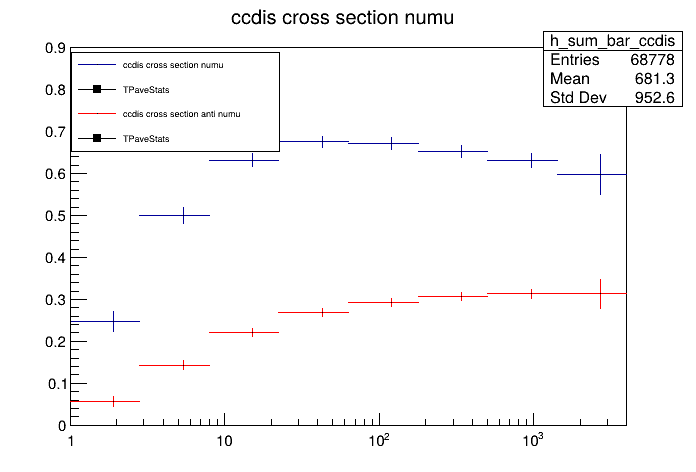

In [38]:
c_comparison_ccdis = r.TCanvas()
h_sum_ccdis.Draw("E")
h_sum_ccdis.SetAxisRange(0,0.9,"Y")
#h_sum_ccdis.SetAxisRange(10,4000.,"X")
h_sum_bar_ccdis.Draw("SAME && E")
h_sum_bar_ccdis.SetLineColor(r.kRed)
c_comparison_ccdis.BuildLegend()
c_comparison_ccdis.SetLogx()
c_comparison_ccdis.Draw()